# Nearest-Neighbour Spacing Profile

Table 1's `mean_nearest_neighbour_distance` is a single number: an average over
every query's distance to its closest neighbour. An average can't tell you
*where the mass sits* -- a workload can post a healthy mean while a chunk of its
queries collapse onto near-duplicate plans, so long as the rest are spread far
enough apart to pull the average back up. This notebook is the full distribution
behind that one number: each query's distance to its nearest neighbour, sorted,
so a hidden duplication cluster shows up as a flat near-zero shelf instead of
disappearing into an average.

Computed on the same **weighted-Jaccard distance over plan-graph features**
(`loader/workload_analysis.py:plan_graph_feature_counter` +
`weighted_jaccard_similarity`) behind Table 1's Vendi score and
mean-nearest-neighbour-distance -- no projection, no PCA/UMAP, no
hyperparameters to second-guess.

Plan graphs come from each workload's already-captured `plans.json` (no Trino
round-trip needed unless one's missing), and the resulting feature records are
further cached to `results/embedding_records_cache.pkl` so re-running this
notebook doesn't even need to re-read/re-parse those. Delete the pickle cache
to force a rebuild from `plans.json`.

## 0 · Config

In [12]:
from pathlib import Path
from collections import Counter
from itertools import combinations
import pickle
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from analysis import resolve_workload_path, load_plans_file, capture_query_plans_for_set
from loader.workload_analysis import (
    dags_from_plan_bundle,
    plan_graph_feature_counter,
    weighted_jaccard_similarity,
)

plt.rcParams.update({
    "figure.dpi": 120, "savefig.dpi": 300, "savefig.bbox": "tight",
    "font.size": 9, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "grid.linewidth": 0.5,
})

WORKLOAD_ROOT = Path("/mnt/primary/Main/Workloads")
CACHE_PATH = Path("results/embedding_records_cache.pkl")
CATALOG = "iceberg"
SCHEMA = "tpcds"
MAX_QUERIES_PER_WORKLOAD = 1000  # only matters on a plans.json miss -- EXPLAIN
                                  # is a live round-trip per query.
PLAN_WORKERS = 8  # concurrent Trino connections, only used if some workload
                   # has no plans.json yet -- see capture_query_plans_for_set(plan_workers=...)

REF   = "tpcds_1200"
OURS  = ["gpt_generated_1000_tpcds_tokens_no_feedback", "gpt_generated_1000_tpcds_tokens"]
BASELINES = ["bootstrapping_lcm_1000_tokens_tpcds",  # alphabetical by display name
             "e2etune_1000_tokens_tpcds",
             "sql_factory_1000_tokens_tpcds",
             "sqlbarber_1000_tokens_tpcds",
             "sqlstorm_1000_tokens_tpcds"]
WORKLOADS = [REF] + BASELINES + OURS

PRETTY = {"tpcds_1200": "TPC-DS",
          "gpt_generated_1000_tpcds_tokens": "DiverSQL (W/ Feedback)",
          "gpt_generated_1000_tpcds_tokens_no_feedback": "DiverSQL (W/O Feedback)",
          "sqlstorm_1000_tokens_tpcds": "SQLStorm", "sqlbarber_1000_tokens_tpcds": "SQLBarber",
          "sql_factory_1000_tokens_tpcds": "SQL-Factory", "e2etune_1000_tokens_tpcds": "E2ETune",
          "bootstrapping_lcm_1000_tokens_tpcds": "Bootstrapping-LCM"}

# Distinct colour per baseline -- NOT a uniform grey -- so the spacing-profile
# lines stay legible; TPC-DS reference is always the same neutral grey. The two
# "ours" variants share the orange family (same system, feedback on/off) at
# different lightness rather than two unrelated hues.
COL = {
    "tpcds_1200": "#9ca3af",
    "bootstrapping_lcm_1000_tokens_tpcds": "#6366f1",  # indigo
    "e2etune_1000_tokens_tpcds":           "#059669",  # emerald
    "sql_factory_1000_tokens_tpcds":       "#0891b2",  # cyan
    "sqlbarber_1000_tokens_tpcds":         "#a855f7",  # violet
    "sqlstorm_1000_tokens_tpcds":          "#db2777",  # pink
    "gpt_generated_1000_tpcds_tokens":     "#ea580c",  # orange (ours, w/ feedback)
    "gpt_generated_1000_tpcds_tokens_no_feedback": "#f59e0b",  # amber (ours, w/o feedback)
}

## 1 · Load plan-graph features (cached pickle, else each workload's plans.json)

Each query becomes a bag-of-features `Counter` (operator types, operator-pair
edges, operator 3-grams) via `plan_graph_feature_counter`. Three tiers, cheapest
first: the pickle cache (skips everything), each workload's already-captured
`<workload>/plans.json` (skips Trino -- this is the common case, since every
workload here has already had its plans captured), and only as a last resort a
live Trino fetch via `capture_query_plans_for_set(...)` for any workload that's
still missing a `plans.json`.

In [9]:
if CACHE_PATH.exists():
    with open(CACHE_PATH, "rb") as f:
        _cache = pickle.load(f)
    records, failures = _cache["records"], _cache["failures"]
    print(f"loaded {len(records)} cached records from {CACHE_PATH} "
          f"(max_queries_per_workload={_cache.get('max_queries_per_workload')})")

    _cached_workloads = {r["workload"] for r in records}
    _missing = [w for w in WORKLOADS if w not in _cached_workloads]
    if _missing:
        print(f"WARNING: cache doesn't cover {_missing} -- delete {CACHE_PATH} "
              "and re-run this cell to rebuild from plans.json / a live fetch.")
else:
    # Prefer each workload's already-captured plans.json over a live Trino
    # EXPLAIN pass -- capture_query_plans_for_set() only actually hits Trino
    # for a workload that's missing one (or has stale plans vs. its q*.sql).
    bundles = {w: load_plans_file(resolve_workload_path(w, WORKLOAD_ROOT)) for w in WORKLOADS}
    need_live = [w for w, b in bundles.items() if b is None]

    if need_live:
        print(f"no plans.json for {need_live} -- capturing live (plan_workers={PLAN_WORKERS})")
        from trino_stack.lakehouse import Lakehouse
        lh = Lakehouse.from_release(
            instance_name="lakehouse-h",
            namespace="pgr24james",
            sync_schemas=True,
            verbose=False,
        )
        capture_query_plans_for_set(
            need_live,
            workload_root=WORKLOAD_ROOT,
            lh=lh,
            catalog=CATALOG,
            schema=SCHEMA,
            plan_workers=PLAN_WORKERS,
        )
        for w in need_live:
            bundles[w] = load_plans_file(resolve_workload_path(w, WORKLOAD_ROOT))
    else:
        print(f"plans.json already present for all {len(WORKLOADS)} workloads -- no Trino needed")

    records, failures = [], []
    for w in WORKLOADS:
        plan_bundle = bundles[w]
        if plan_bundle is None:
            failures.append({"workload": w, "error": "no plans.json even after capture"})
            print(f"  {w}: FAILED (no plans.json)")
            continue
        dags = dags_from_plan_bundle(plan_bundle)
        items = list(dags.items())[:MAX_QUERIES_PER_WORKLOAD]
        for qname, dag in items:
            records.append({"workload": w, "query": qname,
                             "features": plan_graph_feature_counter(dag)})
        print(f"  {w}: {len(items)} query plans")

    CACHE_PATH.parent.mkdir(parents=True, exist_ok=True)
    with open(CACHE_PATH, "wb") as f:
        pickle.dump({"records": records, "failures": failures,
                     "max_queries_per_workload": MAX_QUERIES_PER_WORKLOAD}, f)
    print(f"\ncached {len(records)} records -> {CACHE_PATH}")

if failures:
    print("failures:", failures)

meta = pd.DataFrame({"workload": [r["workload"] for r in records],
                      "query": [r["query"] for r in records]})
print(meta["workload"].value_counts().rename(index=PRETTY))

no plans.json for ['tpcds_1200'] -- capturing live (plan_workers=8)
Checking Trino health ...

=== Capturing plans: tpcds_1200 ===
tpcds_1200: capturing plans for 1208 queries ...
tpcds_1200: wrote /mnt/primary/Main/Workloads/tpcds_1200/plans.json (1208/1208 ok)
  tpcds_1200: 1000 query plans
  bootstrapping_lcm_1000_tokens_tpcds: 1000 query plans
  e2etune_1000_tokens_tpcds: 1000 query plans
  sql_factory_1000_tokens_tpcds: 1000 query plans
  sqlbarber_1000_tokens_tpcds: 1000 query plans
  sqlstorm_1000_tokens_tpcds: 1000 query plans
  gpt_generated_1000_tpcds_tokens_no_feedback: 1000 query plans
  gpt_generated_1000_tpcds_tokens: 1000 query plans

cached 8000 records -> results/embedding_records_cache.pkl
workload
TPC-DS (ref)               1000
Bootstrapping-LCM          1000
E2ETune                    1000
SQL-Factory                1000
SQLBarber                  1000
SQLStorm                   1000
DiverSQL (W/O Feedback)    1000
DiverSQL (W/ Feedback)     1000
Name: count, dtype

## 2 · Pairwise plan-graph distance (weighted Jaccard)

The headline, citable spread number. Computed directly on the raw feature
`Counter`s using the exact same `weighted_jaccard_similarity` that Table 1's
Vendi score and mean-nearest-neighbour-distance are built from, so this number
is consistent with the rest of the paper's diversity claims. `O(n^2)` pairs; a
one-time cost that only needs re-running if the cached records change.

In [10]:
n = len(records)
counters = [r["features"] for r in records]
D = np.zeros((n, n), dtype=np.float32)  # distance = 1 - weighted Jaccard similarity

t0 = time.time()
total_pairs = n * (n - 1) // 2
for idx, (i, j) in enumerate(combinations(range(n), 2)):
    d = 1.0 - weighted_jaccard_similarity(counters[i], counters[j])
    D[i, j] = D[j, i] = d
    if idx % 500_000 == 0 and idx:
        elapsed = time.time() - t0
        print(f"  {idx:,}/{total_pairs:,} pairs ({elapsed:.0f}s elapsed, "
              f"~{elapsed / idx * total_pairs:.0f}s total est.)")

print(f"pairwise distance matrix done in {time.time() - t0:.0f}s")

  500,000/31,996,000 pairs (11s elapsed, ~704s total est.)
  1,000,000/31,996,000 pairs (22s elapsed, ~697s total est.)
  1,500,000/31,996,000 pairs (33s elapsed, ~705s total est.)
  2,000,000/31,996,000 pairs (44s elapsed, ~708s total est.)
  2,500,000/31,996,000 pairs (55s elapsed, ~707s total est.)
  3,000,000/31,996,000 pairs (66s elapsed, ~707s total est.)
  3,500,000/31,996,000 pairs (77s elapsed, ~705s total est.)
  4,000,000/31,996,000 pairs (88s elapsed, ~707s total est.)
  4,500,000/31,996,000 pairs (99s elapsed, ~707s total est.)
  5,000,000/31,996,000 pairs (110s elapsed, ~706s total est.)
  5,500,000/31,996,000 pairs (121s elapsed, ~705s total est.)
  6,000,000/31,996,000 pairs (133s elapsed, ~708s total est.)
  6,500,000/31,996,000 pairs (144s elapsed, ~707s total est.)
  7,000,000/31,996,000 pairs (155s elapsed, ~707s total est.)
  7,500,000/31,996,000 pairs (166s elapsed, ~707s total est.)
  8,000,000/31,996,000 pairs (177s elapsed, ~709s total est.)
  8,500,000/31,996,

## 3 · Nearest-neighbour spacing profile — does the mean hide duplicates?

Table 1's `mean_nearest_neighbour_distance` is an average over **all** pairs, so
it can't tell you *where* the mass sits. A workload can post a high mean while a
chunk of its queries collapse onto near-duplicate plans, as long as the rest are
spread far enough apart to pull the average back up — the all-pairs mean has no
concept of local density. That's exactly the profile SQLStorm shows: its
plan-graph uniqueness ratio is 0.790 (Table 1) yet its mean feature-space
distance is the highest of any workload.

The fix is to look at the **distribution of each query's distance to its single
closest neighbour**, sorted, rather than the one-number average. A generator
that guarantees separation shows a curve that lifts off from zero immediately;
a generator with hidden duplication shows a flat near-zero shelf on the low end
before the curve rises. This plot is that full distribution — Table 1's
`mean_nearest_neighbour_distance` is just its mean.

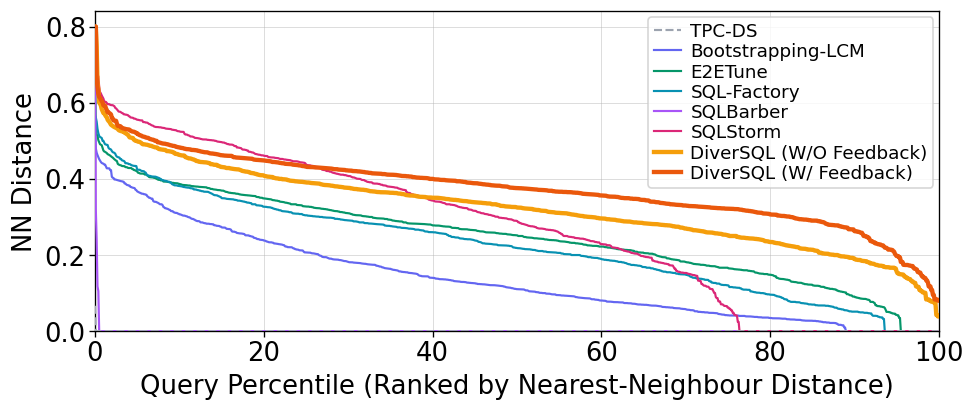

,Share of queries within 0.05 of a neighbour
TPC-DS,99.9%
SQLBarber,99.5%
Bootstrapping-LCM,27.8%
SQLStorm,24.5%
SQL-Factory,9.4%
E2ETune,5.8%
DiverSQL (W/O Feedback),0.4%
DiverSQL (W/ Feedback),0.0%


In [78]:
workload_idx = {w: [i for i, r in enumerate(records) if r["workload"] == w] for w in WORKLOADS}

def within_workload_nn_distances(w):
    """Each query's distance to its closest *other* query in the same workload."""
    idx = workload_idx[w]
    if len(idx) < 2:
        return np.array([])
    sub = D[np.ix_(idx, idx)].copy()
    np.fill_diagonal(sub, np.inf)
    return sub.min(axis=1)

EPS = 0.05  # "near-duplicate" threshold on weighted-Jaccard plan-graph distance
PLOT_WORKLOADS = WORKLOADS

# Match the runtime-distribution figure's sizing.
font_size = 15.5
font_size_leg = 11

# Workloads hugging y=0 that get a zoomed inset of their own.
ZOOM_WORKLOADS = [REF, "sqlbarber_1000_tokens_tpcds"]
# Inset position in axes-fraction coords: [x0, y0, width, height].
INSET_BOUNDS = [0.38, 0.7, 0.25, 0.25]
#INSET_BOUNDS = [0.05, 0.05, 0.25, 0.15]


fig, ax = plt.subplots(figsize=(8.2, 3.5))
ax.spines[:].set_visible(True)


dup_rates = {}
nn_sorted_by_workload = {}
for w in PLOT_WORKLOADS:
    nn = within_workload_nn_distances(w)
    if len(nn) == 0:
        continue
    # Sorted DESCENDING: x=0 (left) is each workload's most-isolated query,
    # x=100 (right) is its most-redundant one.
    nn_sorted = np.sort(nn)[::-1]
    pct = np.linspace(0, 100, len(nn_sorted))
    is_ours = w in OURS
    is_reference = w == REF  # real-query baseline -- dashed, like the runtime figure
    ax.plot(
        pct, nn_sorted,
        linewidth=2.6 if is_ours else 1.3,
        linestyle="--" if is_reference else "-",
        color=COL[w],
        label=PRETTY[w],
        zorder=5 if is_ours else (4 if is_reference else 3),
    )
    dup_rates[w] = float((nn_sorted < EPS).mean())
    nn_sorted_by_workload[w] = nn_sorted


ax.set_xlim(0, 100)
ax.set_ylim(bottom=0)
ax.set_xticks([0, 20, 40, 60, 80, 100])
ax.set_xlabel("Query Percentile (Ranked by Nearest-Neighbour Distance)", fontsize=font_size)
ax.set_ylabel("NN Distance", fontsize=font_size)
ax.grid(linestyle='-', alpha=0.5)
ax.legend(
    fontsize=font_size_leg,
    loc="upper right",
    labelspacing=0.125,
    handlelength=1.5,
    handletextpad=0.5,
    borderpad=0.3,
    borderaxespad=0.3,
)
ax.tick_params(axis='x', labelsize=font_size, pad=2)
ax.tick_params(axis='y', labelsize=font_size, pad=2)

plt.tight_layout()
plt.savefig("results/figures/collapse.pdf")
plt.savefig("results/figures/collapse.png")
plt.show()

(pd.Series(dup_rates, name="pct")
   .rename(index=PRETTY)
   .sort_values(ascending=False)
   .to_frame(f"Share of queries within {EPS} of a neighbour")
   .style.format("{:.1%}"))

In [ ]:
# Percentile range over which each DiverSQL variant lies above EVERY baseline
# in the collapse plot (same descending-sorted NN curves / x-axis as the figure).
COMPARE_TO = BASELINES  # use BASELINES + [REF] to also require beating TPC-DS
GRID = np.linspace(0, 100, 1001)  # common 0.1-percentile grid (robust to unequal n)

def on_grid(w):
    y = nn_sorted_by_workload[w]
    return np.interp(GRID, np.linspace(0, 100, len(y)), y)

base_curves = np.array([on_grid(b) for b in COMPARE_TO])
base_max = base_curves.max(axis=0)       # upper envelope of the comparison set
base_argmax = base_curves.argmax(axis=0)

def runs(mask):
    """Contiguous [start, end] percentile intervals where mask is True."""
    out, i = [], 0
    while i < len(mask):
        if mask[i]:
            j = i
            while j + 1 < len(mask) and mask[j + 1]:
                j += 1
            out.append((round(GRID[i], 1), round(GRID[j], 1)))
            i = j + 1
        else:
            i += 1
    return out

for w in OURS:
    y = on_grid(w)
    strict = y > base_max
    weak = y >= base_max  # counts ties (e.g. both curves at 0 in the tail)
    print(f"\n=== {PRETTY[w]} ===")
    print(f"  strictly above all: {strict.mean():.1%} of percentile range")
    print(f"  at or above all:    {weak.mean():.1%} of percentile range")
    print(f"  strict intervals:   {runs(strict)}")
    lose = ~weak
    if lose.any():
        who = pd.Series([COMPARE_TO[k] for k in base_argmax[lose]]).map(PRETTY).value_counts()
        print(f"  below envelope at {lose.sum()} grid pts; max gap {np.max(base_max[lose] - y[lose]):.4f}")
        print(f"  curve on top where ours loses:\n{who.to_string()}")
    for b in COMPARE_TO:
        print(f"    vs {PRETTY[b]:<18} strictly above on {(y > on_grid(b)).mean():.1%}")